# W1Q3 — Conversion Funnel Over Time
**Question:** How has the full conversion funnel (signup → trial → 3m → 12m) evolved from Jan 2019 to Nov 2022?

**Audience:** Leadership  
**Data source:** `ANALYTICS.MARTS.MART_SUBSCRIPTION_FUNNEL`  
**SQL:** `sql/W1Q3_conversion_funnel_over_time.sql`

---

**Cohort anchor:** Month the free trial started.

> ⚠️ **Data note (DN-001):** Signup and trial data is truncated after December 1, 2022 — only one day
> of December data exists in the source. The SQL caps signup/trial cohorts at **November 2022**.
> 3m and 12m subscription data through December 2022 is valid and included.
> January–March 2023 does not exist in any table despite documentation stating otherwise.

> **Conversion rate note:** `trial_to_3m_rate` and `m3_to_12m_rate` are cumulative ever-converted rates.
> Oct–Nov 2022 cohorts (shown in red dashed) will appear artificially low — insufficient time to convert.
> Exclude them from trend interpretation and focus on cohorts prior to October 2022.

## Setup

In [6]:
import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from src.connection import query

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 130})
PALETTE = sns.color_palette('muted', 6)
INCOMPLETE_COLOR = '#d9534f'

## Load Data

In [7]:
with open('../sql/W1Q3_conversion_funnel_over_time.sql') as f:
    sql = f.read()

df = query(sql)
df['cohort_month'] = pd.to_datetime(df['cohort_month'])

cutoff = pd.Timestamp('2022-10-01')
df['incomplete_cohort'] = df['cohort_month'] >= cutoff

df.tail()

,cohort_month,new_signups,new_trials,trial_to_signup_rate,new_3m_subscribers,trial_to_3m_rate,new_12m_subscribers,m3_to_12m_rate,incomplete_cohort
42,2022-07-01,2924,1240,42.4,726,56.6,291,80.7,False
43,2022-08-01,4170,1693,40.6,823,57.9,383,80.0,False
44,2022-09-01,4095,1674,40.9,952,57.2,415,66.7,False
45,2022-10-01,3993,1705,42.7,1026,60.1,585,0.2,True
46,2022-11-01,3561,1414,39.7,873,54.5,608,0.0,True


## Chart 1 — Monthly Funnel Volume

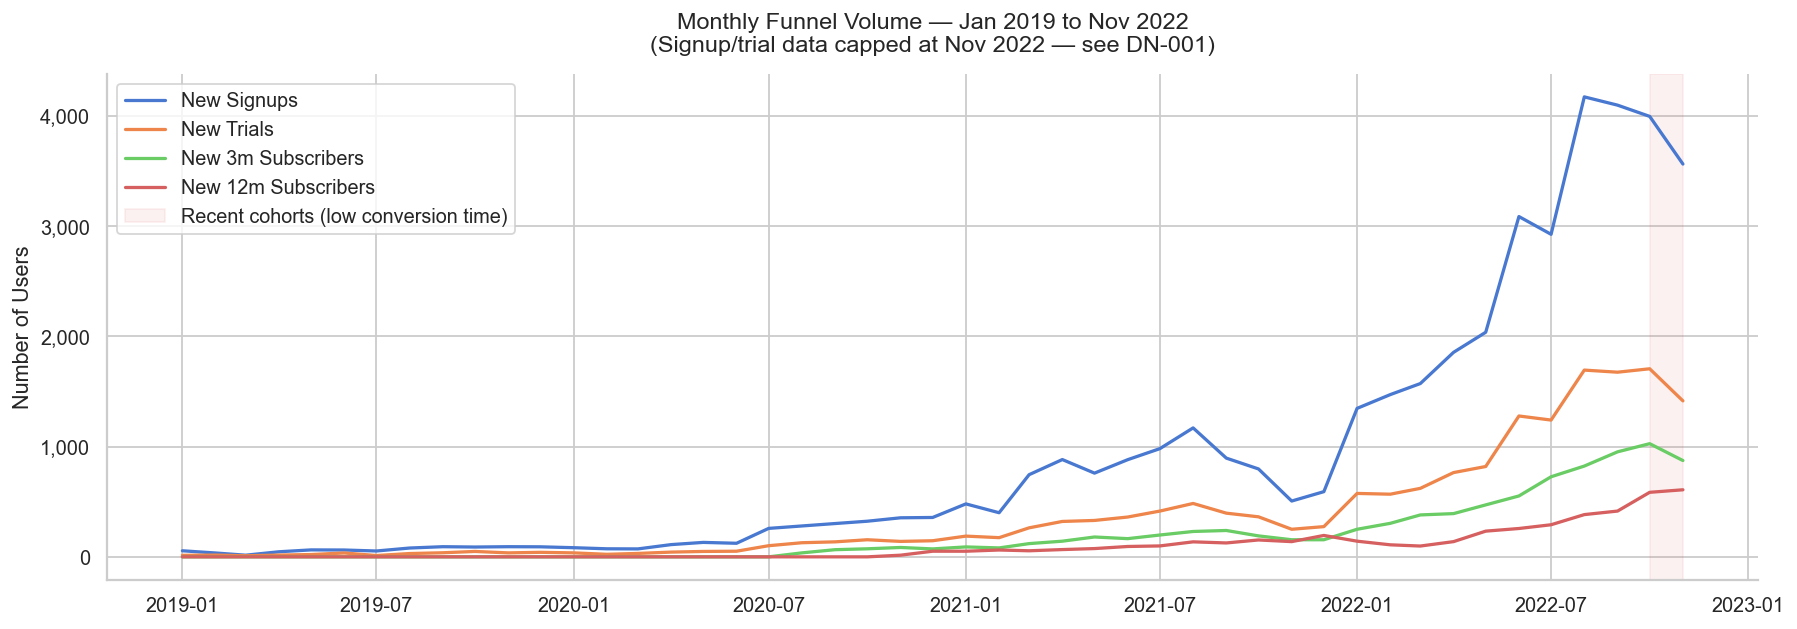

In [8]:
volume_cols = {
    'new_signups':         'New Signups',
    'new_trials':          'New Trials',
    'new_3m_subscribers':  'New 3m Subscribers',
    'new_12m_subscribers': 'New 12m Subscribers',
}

fig, ax = plt.subplots(figsize=(14, 5))
for col, label in volume_cols.items():
    ax.plot(df['cohort_month'], df[col], label=label, linewidth=1.8)

# Shade Oct–Nov 2022: cohorts with insufficient conversion time
ax.axvspan(cutoff, df['cohort_month'].max(), alpha=0.08, color=INCOMPLETE_COLOR, label='Recent cohorts (low conversion time)')
ax.set_title('Monthly Funnel Volume — Jan 2019 to Nov 2022\n(Signup/trial data capped at Nov 2022 — see DN-001)', fontsize=13, pad=12)
ax.set_xlabel('')
ax.set_ylabel('Number of Users')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig('../output/W1Q3_funnel_volume_over_time.png')
plt.show()

## Chart 2 — Conversion Rates Over Time

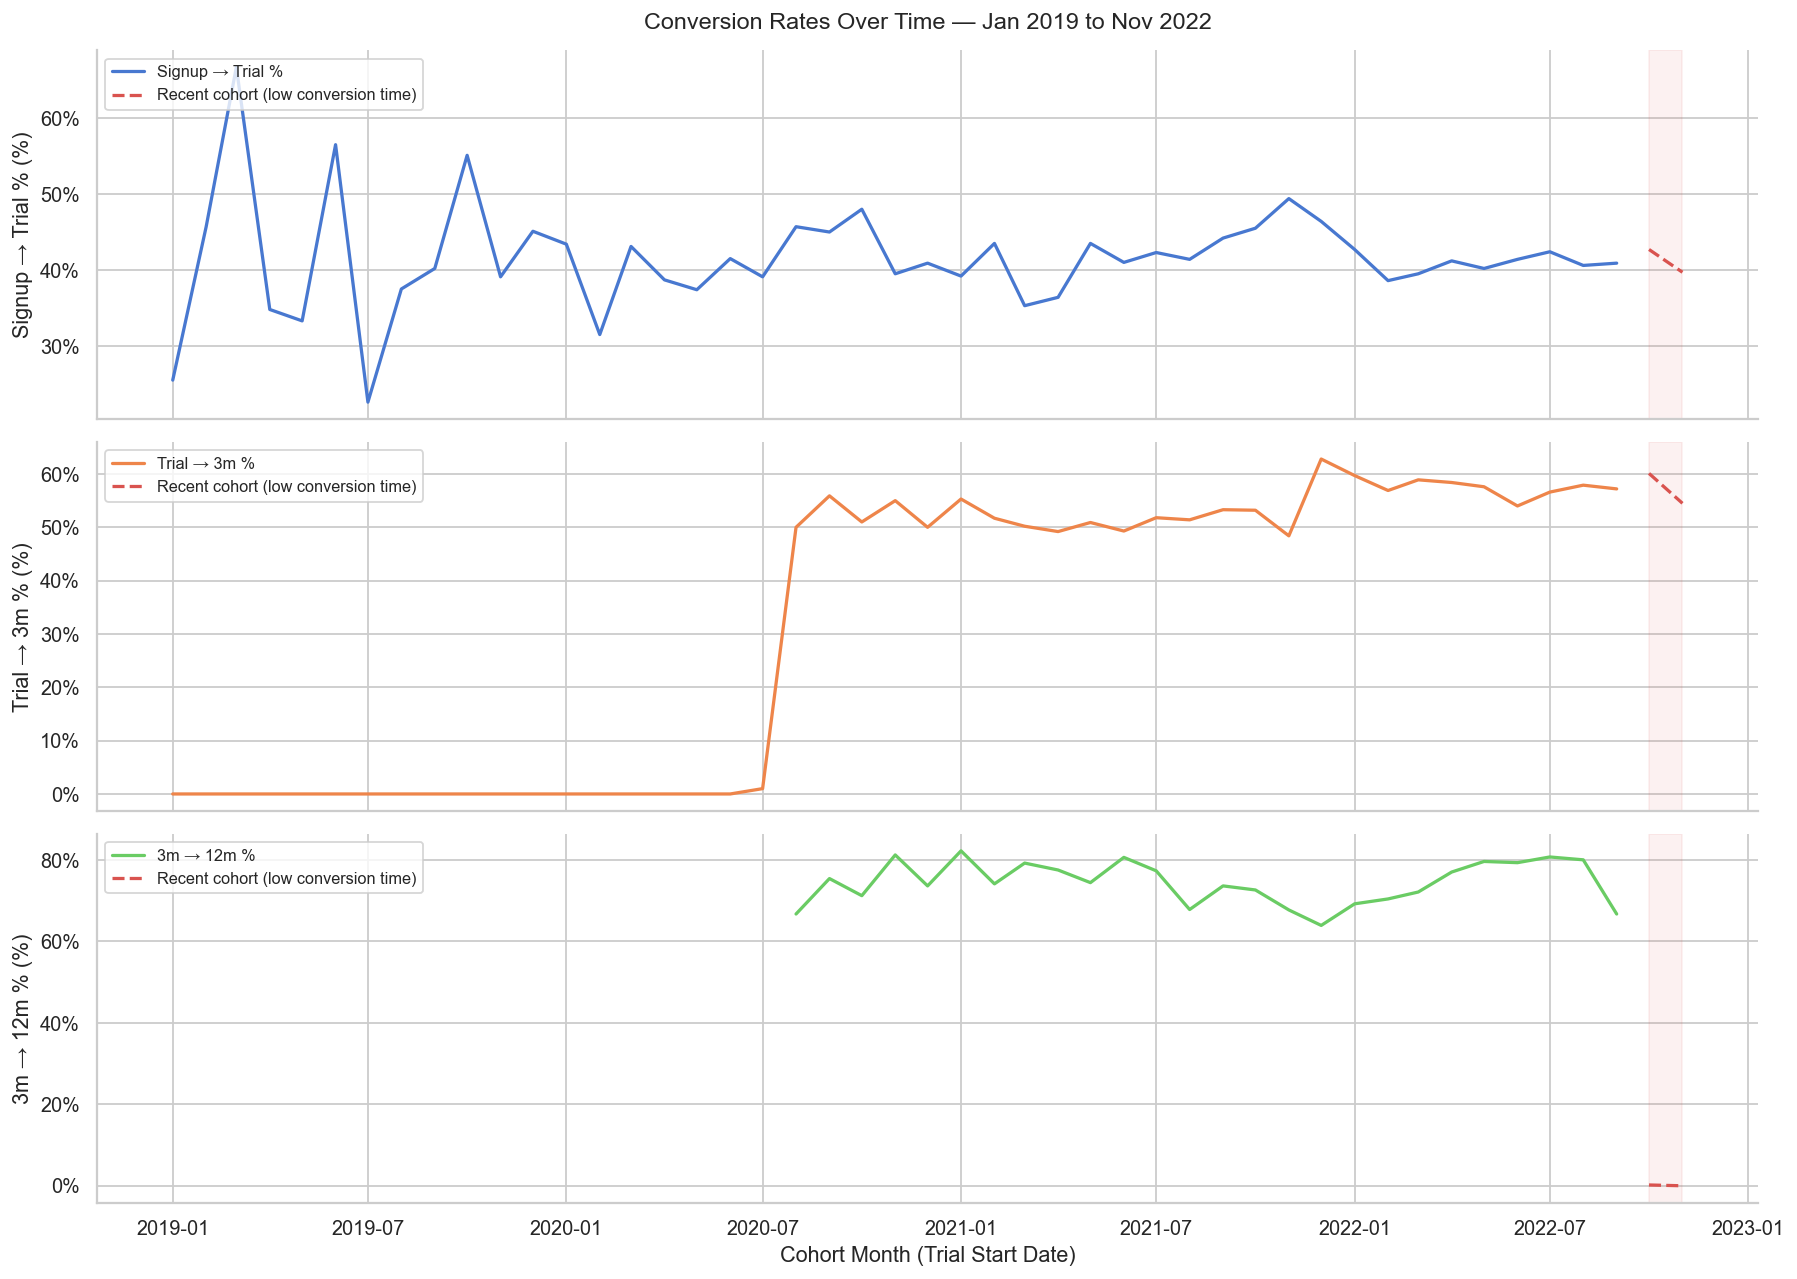

In [9]:
rate_cols = {
    'trial_to_signup_rate': 'Signup → Trial %',
    'trial_to_3m_rate':     'Trial → 3m %',
    'm3_to_12m_rate':       '3m → 12m %',
}

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for ax, (col, label), color in zip(axes, rate_cols.items(), PALETTE):
    complete   = df[~df['incomplete_cohort']]
    incomplete = df[df['incomplete_cohort']]

    ax.plot(complete['cohort_month'], complete[col],
            color=color, linewidth=1.8, label=label)
    ax.plot(incomplete['cohort_month'], incomplete[col],
            color=INCOMPLETE_COLOR, linewidth=1.8, linestyle='--', label='Recent cohort (low conversion time)')
    ax.axvspan(cutoff, df['cohort_month'].max(), alpha=0.08, color=INCOMPLETE_COLOR)
    ax.set_ylabel(f'{label} (%)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    ax.legend(loc='upper left', fontsize=9)
    sns.despine(ax=ax)

axes[0].set_title('Conversion Rates Over Time — Jan 2019 to Nov 2022', fontsize=13, pad=12)
axes[-1].set_xlabel('Cohort Month (Trial Start Date)')
plt.tight_layout()
plt.savefig('../output/W1Q3_conversion_rates_over_time.png')
plt.show()

## Summary Statistics

In [10]:
rate_metrics = list(rate_cols.keys())

full_period = df[~df['incomplete_cohort']][rate_metrics].median()
last_12m    = df[
    (df['cohort_month'] >= '2022-01-01') & (~df['incomplete_cohort'])
][rate_metrics].median()

pd.DataFrame({
    'Metric': list(rate_cols.values()),
    'Median — all time %': full_period.round(1).values,
    'Median — Jan–Sep 2022 %': last_12m.round(1).values, 
})

,Metric,Median — all time %,Median — Jan–Sep 2022 %
0,Signup → Trial %,41.2,40.9
1,Trial → 3m %,50.0,57.6
2,3m → 12m %,74.25,77.0


## Findings

> ⚠️ **Product note:** 3-month and 12-month subscriptions were not offered prior to January 2020.
> The 2019 cohorts represent trial-only activity — all 3m/12m conversion rates for that period are
> structurally zero and should not be included in baseline calculations. The "all-time" medians
> in the summary table above are distorted by this — treat the **Jan 2020 onward** figures as
> the true baseline.

- **Overall growth trend (signups / trials):** Volume grew roughly 10–15x from early 2020 (~200–400 signups/month post-product launch) to peak in mid-2022 (~4,000–4,200 signups/month). Trials followed the same trajectory, peaking at ~1,700/month in Aug–Sep 2022. Growth appears acquisition-driven — the funnel scaled in volume without meaningfully changing conversion rates at the top.

- **Signup → Trial rate over time:** Flat. Median 41.2% all-time, 40.9% in Jan–Sep 2022 — essentially no movement since product launch. Nearly 60% of signups never start a trial, and that has not improved despite a 10x volume increase. This is the largest untapped lever in the funnel — a 5pp improvement here would add ~200 trials/month at 2022 volumes.

- **Trial → 3m conversion rate:** Improving since 2020 launch. All-time median is 50.0%, but this is suppressed by 2019 zeros — the Jan 2020–Sep 2022 median of 57.6% is the more meaningful baseline. The direction is positive and the magnitude (~8pp above early post-launch rates) suggests the product or onboarding has meaningfully improved at converting trial users to paid. Worth investigating what changed to understand whether this is structural or fragile.

- **3m → 12m upsell rate:** Strong and stable since launch. All-time median 74.25% is similarly suppressed by 2019 — the Jan 2020–Sep 2022 median of 77.0% is more representative. Once users commit to a paid 3m subscription, the vast majority upgrade to 12m. The Sep 2022 cohort shows a dip to 66.7% — likely partially explained by insufficient conversion time (3m subscribers from Sep 2022 had at most ~3 months before the pipeline closes Dec 31). Do not interpret this as a structural decline without longer observation.

- **Notable inflection points or seasonality:** No strong seasonal pattern visible in conversion rates — they are structurally stable since the 2020 product launch. Volume shows acceleration from mid-2021 onward, which could reflect increased paid campaign spend, organic growth, or a product/pricing change — worth cross-referencing with . The overall funnel shape (big leak at signup→trial, strong retention at paid stages) has been consistent throughout.

- **Recommendation:** Three priorities: (1) **Attack the signup→trial gap** — at 41% flat since launch, this is the most neglected conversion point. Even understanding *why* 59% of signups never trial would be high-value. (2) **Protect the trial→3m improvement** — the gain since 2020 is real money; identify what drove it so it can be reinforced rather than accidentally reversed. (3) **Do not read the Sep 2022 3m→12m dip as a signal** until those cohorts have had sufficient time — flag as a watch item.